<center>
<h1 style="font-family:verdana">
 💻 🧑 Reconeixement d'entitats anomenades 🧑 💻


<p> 🎯 <b>Objectiu</b>: en aquesta segona part de la pràctica aprendrem a reconèixer entitats anomenades, és a dir, identificar i classificar entitats en una oració que poden ser (en el context de reserva de vols) la ciutat de sortida o d'arribada, la data del mes i el dia, si es de negocis o turista o altres categories específiques. Aquesta tasca se sol plantejar etiquetant cada paraula amb una etiqueta de la categoria de l'entitat a la qual correspon.

Tant la classificació d'intencions (tasca estudiada a la primera part) com el reconeixement d'entitats anomenades (Name Entity Recognition, NER) que veurem en aquesta part són components crucials dels sistemes de processament del llenguatge natural (Natural Language Processing, NLP) i sovint s'utilitzen junts per crear aplicacions d'intel·ligència artificial (IA) conversacionals més sofisticades. Per exemple, en un xatbot, la classificació d'intencions ajuda a entendre la intenció principal de l'usuari, mentre que el reconeixement d'entitats anomenades ajuda a extreure entitats rellevants per proporcionar respostes més contextualitzades.


<p> ✨ <b>Contingut</b>: els passos d'aquesta segona part seran similars a la primera. En primer lloc, analitzarem el conjunt de dades. En segon lloc, prepararem les dades per a poder entrenar el model. I finalment dissenyarem l'arquitectura i entrenarem el model. </p>


<p> ✏ <b>Exercicis</b>: en cada secció anireu trobant exercicis que haureu d'anar resolent. </p>

---

<h2> Índex </h2>

1. [Inspecció del conjunt de dades](#section-one)
  * [Exercici 1](#ex-one)
  * [Exercici 2](#ex-two)
2. [Preprocessament de dades](#section-two)
  * [Exercici 3](#ex-three)
  * [Exercici 4](#ex-four)
3. [Disseny del model i entrenament](#section-three)
  * [Exercici 5](#ex-five)
  * [Exercici 6](#ex-six)
4. [Lliurable](#section-four)

---

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, Reshape, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
from keras.callbacks import EarlyStopping
from keras.utils import register_keras_serializable
import tensorflow.keras.backend as K
# --- Configuración de Seeds (Importante para experimentos) ---
SEED_VALUE = 42
os.environ['PYTHONHASHSEED'] = str(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)
# -----------------------------------------------------------

# --- Configuración de Paralelismo de TensorFlow (Usar todos los threads) ---
num_threads = os.cpu_count()
# 1. Configura el número de threads para operaciones que pueden ser paralelizadas internamente (Intra-op)
tf.config.threading.set_intra_op_parallelism_threads(num_threads)

# 2. Configura el número de threads para operaciones independientes (Inter-op)
tf.config.threading.set_inter_op_parallelism_threads(num_threads)

print(f"TensorFlow configurado para usar {num_threads} threads en la CPU.")


TensorFlow configurado para usar 8 threads en la CPU.


<h1><a name="section-one"> 1. Inspecció del conjunt de dades </a></h1>

In [3]:
!pip install gdown
!gdown "https://drive.google.com/uc?id=1u2wzXvsuscLeFHwXcDwMDaNDy0u_99-t"
!tar -zxf nlu_ATIS_data.tar.gz

Downloading...
From: https://drive.google.com/uc?id=1u2wzXvsuscLeFHwXcDwMDaNDy0u_99-t
To: c:\Users\mafra\Desktop\Q5\TVD\TVD_P2\nlu_ATIS_data.tar.gz

  0%|          | 0.00/122k [00:00<?, ?B/s]
100%|██████████| 122k/122k [00:00<00:00, 2.17MB/s]


En aquesta segona part de la pràctica utilitzarem el mateix dataset que a la primera part, però en aquest cas utilitzarem la **primera columna** que correspon a les **oracions** introduïdes pels usuaris i la **segona columna** on trobarem les oracions d'entrada en format **BILOU**.

El format BILOU  és un esquema d'etiquetatge que es fa servir a les tasques de reconeixement d'entitats anomenades. El nom *BILOU* representa les etiquetes utilitzades en aquest esquema:

*   **B** - Beginning: primer token d'una entitat.
*   **I** - Inside: token dins d'una entitat.
*   **L** - Last: últim token de l'entitat.
*   **O** - Outside: token que no pertany a cap entitat.
*   **U** - Unit: entitats d'un sol token

A continuació, carregarem les dades per visualitzar i poder entendre millor aquestes etiquetes.

---

 <h1><a name="ex-one"><center> ✏ Exercici 1 ✏</a></h1>

A continuació us demanem que carregueu els dos CSVs de la carpeta `data`: `train.csv`, `test.csv` utilitzant pandas. Recorda que aquests CSVs no tenen capçalera. Agafeu les 900 últimes lineas del fitxer `train.csv` per crear un dataframe per validació.

In [3]:
#TODO

train_data = pd.read_csv('./data/train.csv', header=None)
val_data = train_data.tail(900)
train_data = pd.read_csv('./data/train.csv', header=None, nrows=4078)
test_data = pd.read_csv('./data/test.csv', header=None)

print('Training size:', len(train_data))
print('Validation dataset size:', len(val_data))
print('Test dataset size:', len(test_data))

Training size: 4078
Validation dataset size: 900
Test dataset size: 893


---

 <h1><a name="ex-two"><center> ✏ Exercici 2 ✏</a></h1>

Tal com hem introduït abans, per a aquest exercici ens centrarem en la **primera** i la **segona** columna. Per tant, ara us demanem que guardeu en les següents variables, les llistes corresponents a les oracions i a les etiquetes de les tres particions (`train`, `validation` i `test`).

In [4]:
#TODO
train_sentences = list(train_data[0])
train_labels = list(s.replace('"', '') for s in train_data[1])

val_sentences = list(val_data[0])
val_labels = list(s.replace('"', '') for s in val_data[1])

test_sentences = list(test_data[0])
test_labels = list(s.replace('"', '') for s in test_data[1])

---

Si tot ha anat bé ja podem analitzar quin aspecte té el format BILOU.

In [5]:
print(train_sentences[0])
print(train_labels[0])

i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
 O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time O O O B-toloc.city_name O B-arrive_time.time O O B-arrive_time.period_of_day


Aquest hauria de ser el resultat obtingut si executeu la cel·la anterior:

```


i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
 "O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time O O O B-toloc.city_name O B-arrive_time.time O O B-arrive_time.period_of_day"


```

En aquest exemple, `boston` i `838 am` corresponen a l'entitat "ciutat de sortida" i a l'entitat "hora de sortida" respectivament (`fromloc.city_name`,`depart_time.time`). `838` correspon al primer token que pertany la entitat `depart_time.time` i `am` al segon de la mateixa entitat. Els tokens com `i` o `want` no pertanyen a cap entitat.

In [6]:
print(train_sentences[1])
print(train_labels[1])

what flights are available from pittsburgh to baltimore on thursday morning
 O O O O O B-fromloc.city_name O B-toloc.city_name O B-depart_date.day_name B-depart_time.period_of_day


I aquest hauria de ser el resultat de la cel·la anterior:

```
what flights are available from pittsburgh to baltimore on thursday morning
 O O O O O B-fromloc.city_name O B-toloc.city_name O B-depart_date.day_name B-depart_time.period_of_day
```

En l'anterior exemple, `what`, `flights`, `are`, `available`, `from`, `to` i `on` estan etiquetades com a no pertanyents a cap entitat. I, en canvi, `pittsburgh` pertany a l'entitat d'un sol token anomenada ciutat d'arribada (`toloc.city_name`). També hi ha entitats compostes com `baltimore` que pertany a l'entitat ciutat de sortida (`fromloc.city_name`) i `thursday morning` que pertanyen a les entitats data de sortida (`depart_date.day_name`, `depart_time.period_of_day`).

Vegem-ne la llista completa d'entitats.

In [7]:
from collections import Counter

def count_unique_entities(list_of_label_sentences):
  flat_labels = []
  for labels in list_of_label_sentences:
    flat_labels += labels.split()
  c = Counter(flat_labels)
  return len(c), list(c.keys())

num_unique_entities, unique_entities = count_unique_entities(train_labels)

print("Number of different entities:", num_unique_entities)

print("Unique entities:", unique_entities)

Number of different entities: 119
Unique entities: ['O', 'B-fromloc.city_name', 'B-depart_time.time', 'I-depart_time.time', 'B-toloc.city_name', 'B-arrive_time.time', 'B-arrive_time.period_of_day', 'B-depart_date.day_name', 'B-depart_time.period_of_day', 'B-flight_time', 'I-flight_time', 'I-fromloc.city_name', 'B-cost_relative', 'B-round_trip', 'I-round_trip', 'B-fare_amount', 'I-fare_amount', 'B-depart_date.today_relative', 'I-toloc.city_name', 'B-city_name', 'B-stoploc.city_name', 'B-toloc.airport_code', 'B-depart_time.time_relative', 'B-class_type', 'I-class_type', 'B-depart_date.date_relative', 'B-airline_name', 'I-airline_name', 'B-arrive_time.time_relative', 'B-depart_time.start_time', 'I-depart_time.start_time', 'B-depart_time.end_time', 'I-depart_time.end_time', 'B-fromloc.airport_name', 'I-fromloc.airport_name', 'B-toloc.state_name', 'B-depart_date.day_number', 'I-depart_date.day_number', 'B-depart_date.month_name', 'B-mod', 'B-fare_basis_code', 'B-transport_type', 'B-flight_m

<h1><a name="section-two"> 2. Preprocessament de dades </a></h1>

El processament de les dades serà semblant al de la primera part d'aquesta pràctica.

---

 <h1><a name="ex-three"><center> ✏ Exercici 3 ✏</a></h1>

En aquest exercici us demanem que realitzeu els passos següents per preparar les dades.

 1. El primer pas serà construir el vocabulari a partir de les paraules presents a les oracions d'entrenament.

2. El segon pas serà convertir les oracions en seqüències de nombres enters usant el tokenitzador.

3. El tercer pas serà guardar la longitud original de cada oració. Això ens serà útil per evaluar el nostre model sense tenir en compte el padding.

3. Finalment, per aconseguir que totes les seqüències tinguen la mateixa longitud, fixarem la longitud segons la màxima trobada a l'entrenament i afegirem zeros a les oracions de menor longitud.

Recordeu que podeu consultar com fer-ho a la documentació de la llibrería:
* <a href="https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer"> Tokenizer </a>
* <a href="https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences"> Pad Sequences </a>




In [8]:
#TODO
num_words=500
tokenizer = Tokenizer(num_words)
tokenizer.fit_on_texts(train_sentences)

vocab = tokenizer.word_index #diccionario con todas las palabras del corpus y su índice ordenado por frecuencia.

train_sequences = tokenizer.texts_to_sequences(train_sentences)
max_sequence_length = max(map(len, train_sequences))
len_train_sequences = [len(seq) for seq in train_sequences]
train_pad_sequences = pad_sequences(train_sequences, maxlen=max_sequence_length, padding='post')

val_sequences = tokenizer.texts_to_sequences(val_sentences)
len_val_sequences = [len(seq) for seq in val_sequences]
val_pad_sequences = pad_sequences(val_sequences, maxlen=max_sequence_length, padding='post')

test_sequences = tokenizer.texts_to_sequences(test_sentences)
len_test_sequences = [len(seq) for seq in test_sequences]
test_pad_sequences = pad_sequences(test_sequences, maxlen=max_sequence_length, padding='post')

In [9]:
train_pad_sequences[0]

array([ 12,  69,   1,  38,   2,   9,  64, 415,  84,  17,  75,  16,  13,
        64, 493,  16,   4,  36,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0], dtype=int32)


---



Tal com vam fer a la primera part, aquí també hem de convertir les diferents classes d'entitats en vectors one-hot.

---

 <h1><a name="ex-four"><center> ✏ Exercici 4 ✏</a></h1>

Per aconseguir-ho haureu de seguir els passos següents.

 1. En primer lloc, haureu d'esbrinar quantes etiquetes diferents hi ha. Podeu prendre com a exemple la funció `count_unique_entities` per fer-ho. Tingueu en compte que haureu de modificar la funció, ja que per exemple aquesta funció considera que `B-depart_time.time`, `I-depart_time.time`, `L-depart_time.time`, `U-depart_time.time` són la mateixa entitat. En aquest exercici, necessitarem comptar-les per separat. També l'entitat O ha de ser considerada com una classe.

 2. El segon pas serà codificar les diferents classes trobades en etiquetes numèriques. Tingueu en compte que cada paraula de l'oració té una etiqueta i, per tant, per a cada oració tindrem una llista d'etiquetes. El *padding* el codificarem amb l'etiqueta corresponent a **O** (outside). Per ajudar-vos hem preparat el processament per a les etiquetes d'entrenament, intenteu comprendre el que es fa i així repetir-ho per a la partició de validació i test.

 3. Finalment, haureu de convertir les diferents classes a vectors one-hot. Recordeu de nou que per a cada oració tindrem una llista de vectors one-hot.


 Podeu consultar els apartats de la documentació:
 * <a href=https://www.tensorflow.org/guide/keras/understanding_masking_and_padding> Masking and Padding </a>

 * <a href=https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical> To Categorical </a>



In [10]:
print(test_pad_sequences.shape)

(893, 45)


In [11]:
#TODO
#Step 1
def count_unique_entities(list_of_label_sentences):
    """Devuelve la cantidad de etiquetas totales (contando O) y además devuelve cuáles son."""
    flat_labels = []
    for labels_sentence in list_of_label_sentences:
      # Separem la cadena d'etiquetes en una llista d'etiquetes per token
      flat_labels.extend(labels_sentence.split())
    # Utilitzem np.unique per obtenir la llista ordenada i única
    unique_entities = sorted(list(np.unique(flat_labels)))
    return len(unique_entities), unique_entities


num_unique_entities, unique_entities = count_unique_entities(train_labels)

print("Number of different entities:", num_unique_entities)
print("Unique entities:", unique_entities)

# Step 2

def remove_sentences(list_labels, list_sequences):
  idx_to_remove = []
  labels_to_remove = []
  for idx, labels in enumerate(list_labels):
    for label in labels:
      if label not in unique_entities:
        idx_to_remove.append(idx)
        labels_to_remove.append(label)

  labels = [elem for i, elem in enumerate(list_labels) if i not in idx_to_remove]
  sequences = [elem for i, elem in enumerate(list_sequences) if i not in idx_to_remove]
  return labels, np.array(sequences)

# 1. Inicializar y ajustar LabelEncoder
label_encoder = LabelEncoder()
# Ajustamos SOLO con las entidades de token ÚNICAS obtenidas del entrenamiento
label_encoder.fit(unique_entities)

num_classes = len(label_encoder.classes_)
o_label_index = label_encoder.transform(['O'])[0] # Obtenemos el índice numérico de 'O'

# Necesitamos la longitud máxima de la secuencia del Ejercicio 3
# max_sequence_length = max(map(len, train_sequences))
# len_train_sequences = max_sequence_length

max_len = max_sequence_length

# --- Preparación para la limpieza y el padding ---

# Función auxiliar para aplicar transformación numérica y padding con 'O'
def transform_and_pad(labels_list, encoder, max_len, o_index):
    # Convertimos cada oración de etiquetas en una secuencia numérica
    numerical_sequences = [encoder.transform(tokens) for tokens in labels_list]

    # Aplicamos padding. El valor de padding debe ser el índice de 'O'
    return pad_sequences(
        numerical_sequences,
        maxlen=max_len,
        padding='post',
        value=o_index
    )


# 2. y 3. Limpieza de Validación y Test (Usando remove_sentences adaptada)

# Convertir las etiquetas de test y validación a listas de tokens ANTES de pasarlas a remove_sentences
_val_labels = [label.split() for label in val_labels]
_test_labels = [label.split() for label in test_labels]

# Aplicamos la limpieza. Aquí ajustamos las secuencias de palabras y las etiquetas.
val_labels_cleaned, val_pad_sequences_cleaned = remove_sentences(_val_labels, val_pad_sequences)
test_labels_cleaned, test_pad_sequences_cleaned = remove_sentences(_test_labels, test_pad_sequences)

# Actualizamos los datos:
# Las etiquetas de train no necesitan limpieza si unique_entities se obtuvo correctamente de ellas.
train_labels_tokens = [label.split() for label in train_labels] # Convertimos a lista de listas de tokens

val_pad_sequences = val_pad_sequences_cleaned # Usamos las secuencias de palabras limpiadas
test_pad_sequences = test_pad_sequences_cleaned # Usamos las secuencias de palabras limpiadas

# 4. Codificación numérica con Padding para todas las particiones

# Entrenamiento:
train_pad_labels = transform_and_pad(train_labels_tokens, label_encoder, max_len, o_label_index)

# Validación (usando las etiquetas limpiadas):
val_pad_labels = transform_and_pad(val_labels_cleaned, label_encoder, max_len, o_label_index)

# Test (usando las etiquetas limpiadas):
test_pad_labels = transform_and_pad(test_labels_cleaned, label_encoder, max_len, o_label_index)

# Verificación de las dimensiones para el siguiente paso
print(f"Índice de 'O' (Outside) para el padding: {o_label_index}")
print(f"Shape de las etiquetas de entrenamiento (Numérico con Padding): {train_pad_labels.shape}")

#Step 3
# Convertir a One-Hot
train_labels_one_hot = to_categorical(train_pad_labels, num_classes=num_classes)
val_labels_one_hot = to_categorical(val_pad_labels, num_classes=num_classes)
test_labels_one_hot = to_categorical(test_pad_labels, num_classes=num_classes)

# Verificación final
print(f"\nNúmero total de clases: {num_classes}")
print(f"Shape de las etiquetas de entrenamiento (One-Hot): {train_labels_one_hot.shape}")
print(f"Shape de las etiquetas de validación (One-Hot): {val_labels_one_hot.shape}")
print(f"Shape de las etiquetas de test (One-Hot): {test_labels_one_hot.shape}")

Number of different entities: 119
Unique entities: [np.str_('B-aircraft_code'), np.str_('B-airline_code'), np.str_('B-airline_name'), np.str_('B-airport_code'), np.str_('B-airport_name'), np.str_('B-arrive_date.date_relative'), np.str_('B-arrive_date.day_name'), np.str_('B-arrive_date.day_number'), np.str_('B-arrive_date.month_name'), np.str_('B-arrive_date.today_relative'), np.str_('B-arrive_time.end_time'), np.str_('B-arrive_time.period_mod'), np.str_('B-arrive_time.period_of_day'), np.str_('B-arrive_time.start_time'), np.str_('B-arrive_time.time'), np.str_('B-arrive_time.time_relative'), np.str_('B-city_name'), np.str_('B-class_type'), np.str_('B-connect'), np.str_('B-cost_relative'), np.str_('B-day_name'), np.str_('B-day_number'), np.str_('B-days_code'), np.str_('B-depart_date.date_relative'), np.str_('B-depart_date.day_name'), np.str_('B-depart_date.day_number'), np.str_('B-depart_date.month_name'), np.str_('B-depart_date.today_relative'), np.str_('B-depart_date.year'), np.str_('B

In [12]:
print(len(test_pad_sequences), len(train_labels_one_hot), len(val_pad_sequences), len(val_labels_one_hot))


885 4078 897 897


<h1><a name="section-three"> 3. Disseny del model i entrenament </a></h1>

---
<h1><a name="ex-five"><center> ✏ Exercici 5 ✏</a></h1>

De forma similar com féreu a la primera part de la pràctica us demanem que dissenyeu l'arquitectura i entreneu el model. Podeu fer servir una arquitectura similar. Ara bé, per capturar les dependències seqüencials podeu canviar la capa de GlobalMaxPooling1D per una LSTM.

In [13]:
s = train_pad_labels.shape
train_flat_labels = train_pad_labels.reshape(s[0]*s[1])
train_unq_labels = np.unique(train_flat_labels)
print(train_flat_labels.shape, train_unq_labels)

(183510,) [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118]


In [14]:
class TransformerBlock(keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.ffn = keras.Sequential(
            [
                keras.layers.Dense(ff_dim, activation="relu"),
                keras.layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = keras.layers.Dropout(rate)
        self.dropout2 = keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class TokenAndPositionEmbedding(keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = keras.layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.pos_emb = keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, inputs):
        maxlen = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        position_embeddings = self.pos_emb(positions)
        token_embeddings = self.token_emb(inputs)
        return token_embeddings + position_embeddings

In [15]:
def categorical_focal_loss_fn_3d(y_true, y_pred, gamma=2.0, alpha=0.25):
    """
    Función Focal Loss modificada para asegurar que maneja entradas 3D (Sequence Tagging).
    Asegura que el aplanado se hace a 2D antes de aplicar la lógica de pérdida.
    """
    gamma = float(gamma)
    alpha = float(alpha)
    
    # Aplanar las dimensiones de secuencia y batch: (batch_size * max_len, num_classes)
    y_true_flattened = K.reshape(y_true, (-1, K.shape(y_true)[-1]))
    y_pred_flattened = K.reshape(y_pred, (-1, K.shape(y_pred)[-1]))
    
    epsilon = K.epsilon()
    y_pred_flattened = K.clip(y_pred_flattened, epsilon, 1.0 - epsilon)
    
    p_t = K.sum(y_true_flattened * y_pred_flattened, axis=-1)
    cross_entropy = -K.sum(y_true_flattened * K.log(y_pred_flattened), axis=-1)
    loss = alpha * K.pow(1.0 - p_t, gamma) * cross_entropy
    
    # El resultado 'loss' es 1D (por elemento). Keras calculará el promedio por lote.
    return loss

def categorical_focal_loss_temporal(y_true, y_pred, gamma=2.0, alpha=0.25):
    """
    Focal Loss que devuelve una pérdida por cada paso de tiempo (temporal).
    Shape de salida: (batch_size, sequence_length)
    """
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    
    # NO se aplanan los tensores. Las operaciones se aplican sobre el último eje.
    p_t = K.sum(y_true * y_pred, axis=-1)
    cross_entropy = -K.sum(y_true * K.log(y_pred), axis=-1)
    loss = alpha * K.pow(1.0 - p_t, gamma) * cross_entropy

    return loss # Devuelve un tensor 2D

# 2. Defineix la pèrdua sense arguments per defecte, si vols utilitzar la signatura original.
# En aquest cas, per a utilitzar els valors gamma=2.0 i alpha=0.25 en la compilació:
focal_loss = lambda y_true, y_pred: categorical_focal_loss_fn_3d(y_true, y_pred, gamma=2.0, alpha=0.25)
focal_loss_temporal = lambda y_true, y_pred: categorical_focal_loss_temporal(y_true, y_pred, gamma=2.0, alpha=0.25)
# macro_f1 = [tf.keras.metrics.F1Score(average='macro')]
from tensorflow.keras.metrics import Metric, F1Score
class F1Score_3D(Metric):
    """
    Métrica F1 adaptada para entradas 3D (Sequence Tagging).
    Asegura que el aplanado se hace a 2D antes del cálculo de F1Score.
    """
    def __init__(self, average='macro', name='macro_f1_3d', **kwargs):
        super(F1Score_3D, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # Inicializa la métrica interna F1Score de Keras
        self.f1_metric = F1Score(average=average, threshold=None)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # 1. Aplanar y_true y y_pred de 3D a 2D
        # y_true/y_pred: (batch_size, max_len, num_classes) -> (batch_size * max_len, num_classes)
        y_true_flattened = tf.reshape(y_true, (-1, self.num_classes))
        y_pred_flattened = tf.reshape(y_pred, (-1, self.num_classes))
        
        # 2. Opcional pero recomendado para Sequence Tagging:
        # Aquí podrías filtrar el padding. Si el padding es la clase 0, puedes eliminar
        # todas las filas donde y_true_flattened tiene un 1 en la posición 0.
        # Esto depende de cómo manejas el padding en tus etiquetas. Si no usas
        # padding en las etiquetas o usas un 'mask', esto no es necesario.
        
        # 3. Actualizar el estado de la métrica interna con los tensores 2D
        self.f1_metric.update_state(y_true_flattened, y_pred_flattened, sample_weight=sample_weight)

    def result(self):
        return self.f1_metric.result()

    def reset_state(self):
        self.f1_metric.reset_state()

num_classes = 119
macro_f1 = [F1Score_3D(average='macro')]

In [17]:
#TODO
vocab_size = num_words + 1  # +1 para el token de padding
embedding_dim = 128 
lstm_units = 128 

# Definim el model
modelo_basico = Sequential([
    # Capa Embedding
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),

    # LSTM
    Bidirectional(
        LSTM(
            units=lstm_units,
            return_sequences=True
        )
    ),

    # Capa Dense amb ReLU
    Dense(128, activation='relu'),

    # Capa Dense amb Softmax (sortida)
    Dense(num_classes, activation='softmax')

])

# 3. Compilación y Entrenamiento
epochs = 50
batch_size = 128

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
modelo_basico.compile(
    optimizer='adam',
    loss=focal_loss,
    metrics=macro_f1
)
print("\nIniciando el entrenamiento del modelo...")
history = modelo_basico.fit(
    train_pad_sequences,
    train_labels_one_hot,
    validation_data=(val_pad_sequences, val_labels_one_hot),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)
# Evaluate the model on the test set
print("\nEvaluando el modelo en el conjunto de prueba...")
loss, accuracy = modelo_basico.evaluate(
    test_pad_sequences, 
    test_labels_one_hot, 
    verbose=0 
)
print(f"Test accuracy: {accuracy:.2f}")



Iniciando el entrenamiento del modelo...
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - loss: 0.2533 - macro_f1_3d: 0.0091 - val_loss: 0.0948 - val_macro_f1_3d: 0.0080
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - loss: 0.0887 - macro_f1_3d: 0.0080 - val_loss: 0.0845 - val_macro_f1_3d: 0.0080
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 216ms/step - loss: 0.0786 - macro_f1_3d: 0.0107 - val_loss: 0.0731 - val_macro_f1_3d: 0.0132
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - loss: 0.0638 - macro_f1_3d: 0.0229 - val_loss: 0.0582 - val_macro_f1_3d: 0.0291
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 310ms/step - loss: 0.0505 - macro_f1_3d: 0.0434 - val_loss: 0.0479 - val_macro_f1_3d: 0.0565
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 300ms/step - loss: 0.0412 - macro_f1_3d: 0.0673 - val_loss: 0.0400 - val_macro_f1_3d: 0.0839
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 292ms/step - loss: 0.0329 - macro_f1_3d: 0.1107 - val_loss: 0.0322 - val_macro_f1_3d: 0.1422
Epoch 8/50
32/32 

In [18]:
preds = modelo_basico.predict(test_pad_sequences)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [19]:
preds.shape

(885, 45, 119)

In [20]:
def preds_to_index(preds, seq_lens):
  '''
  Turn predictions to numerical indexes, flatten the sentences and discard padding.
  '''
  idx_preds = []
  for pred, seq_len in zip(preds,seq_lens):
      for l in range(seq_len):
        idx_preds.append(np.argmax(pred[l]))
  return idx_preds



Com ja sabeu, NER es una tasca on les dades estan molt desbalancejades. La gran majoria de les nostres etiquetes serán 'O' (outside). Es pot donar el cas on el model tingui una accuracy molt alta predint sempre 'O'.

Per mesurar millor com de bó és el nostre model, calcularem la F1 score per cada classe, així com la mitjana (macro average). Quan prepareu el vostre document, heu de reportar aquesta mitjana com a mètrica del vostre model, no l'acuracy.

In [21]:

test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
preds_idx = preds_to_index(preds, len_test_sequences)
print(classification_report(test_labels_idx, preds_idx, zero_division=1.0))

              precision    recall  f1-score   support

           0       1.00      0.00      0.00        21
           1       1.00      0.76      0.86        29
           2       0.94      0.85      0.89        79
           3       0.00      0.00      0.00         8
           4       0.89      0.44      0.59        18
           5       1.00      1.00      1.00         1
           6       0.83      0.71      0.77         7
           7       0.50      0.33      0.40         3
           8       0.50      0.33      0.40         3
          12       1.00      1.00      1.00         2
          13       1.00      0.00      0.00         1
          14       0.83      0.77      0.80        13
          15       0.85      0.79      0.81        14
          16       0.96      0.58      0.72        43
          17       0.96      0.96      0.96        23
          18       1.00      1.00      1.00         6
          19       1.00      1.00      1.00        33
          20       1.00    

In [22]:
import re

def extract_macro_f1(report_string):
    """
    Extreu la puntuació Macro F1 de la sortida de text de classification_report.
    """
    # Dividim el text per línies
    lines = report_string.split('\n')
    
    for line in lines:
        if 'macro avg' in line:
            # Utilitzem re.split per dividir la línia per qualsevol quantitat d'espais en blanc
            # i filtrem els elements buits que puguin quedar.
            tokens = [t for t in re.split(r'\s+', line.strip()) if t]
            
            # El valor F1-score macro és a la 5a posició (índex 4)
            # tokens[0] = 'macro'
            # tokens[1] = 'avg'
            # tokens[2] = 'precision' 
            # tokens[3] = 'recall' 
            # tokens[4] = 'f1-score' 
            
            try:
                macro_f1 = float(tokens[4])
                return macro_f1
            except (ValueError, IndexError) as e:
                # Si hi ha un error en l'extracció, retornem None i imprimim l'error
                print(f"Error extraient F1-Macro: {e}. Tokens trobats: {tokens}")
                return None
    return None


A continuació podeu veure algunes prediccions del model.

In [23]:
def print_trimmed_predictions(test_sentences, test_labels, predicted_labels, num_samples=10):
    """
    Imprime las oraciones, las etiquetas originales y las etiquetas predichas, 
    recortando el padding (etiquetas sobrantes) de las predicciones.
    
    Args:
        test_sentences (list): Lista de las oraciones de prueba.
        test_labels (list): Lista de las etiquetas originales (ya recortadas).
        predicted_labels (list): Lista de las etiquetas predichas por el modelo (con padding).
        num_samples (int): Número de ejemplos a imprimir.
    """
    print("--- Resultados de Predicción (Padding Recortado) ---")
    
    for i in range(0, min(num_samples, len(test_sentences))):
        
        # 1. Determinar la longitud real de la frase. 
        #    Asumimos que test_labels[i] es una cadena de etiquetas separadas por espacios.
        if isinstance(test_labels[i], str):
            real_length = len(test_labels[i].split())
        else:
            # Si test_labels[i] ya es una lista, usamos su longitud directamente.
            real_length = len(test_labels[i]) 
            
        
        # 2. Recortar la predicción (que tiene 45 etiquetas) a la longitud real.
        trimmed_predicted_labels = predicted_labels[i][:real_length]
        
        # 3. Formatear la salida.
        # Quitamos el np.str_ y unimos las etiquetas para una mejor visualización.
        
        print('Sentence: ', test_sentences[i])
        print('Original label: ', test_labels[i])
        
        # Eliminamos el prefijo 'np.str_' para que se vea limpio
        clean_predicted_labels = [str(label) for label in trimmed_predicted_labels]
        
        print('Predicted label: ', " ".join(clean_predicted_labels))
        print("-" * 40)

In [24]:
# 1. Obtener las probabilidades y convertirlas a índices
probs = modelo_basico.predict(test_pad_sequences)
_predicted_labels = np.argmax(probs, axis=2)

# 2. Decodificar los índices a etiquetas (ESTO AÚN TIENE EL PADDING DE 45)
# El resultado es una lista de listas de etiquetas (strings), todas de longitud 45.
predicted_labels = [list(label_encoder.inverse_transform(label)) for label in _predicted_labels]

# 3. Llamar a la función para imprimir solo las etiquetas relevantes
print_trimmed_predictions(
    test_sentences=test_sentences, 
    test_labels=test_labels, 
    predicted_labels=predicted_labels, 
    num_samples=10
)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
--- Resultados de Predicción (Padding Recortado) ---
Sentence:  i would like to find a flight from charlotte to las vegas that makes a stop in st. louis
Original label:   O O O O O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name O O O O O B-stoploc.city_name I-stoploc.city_name
Predicted label:  O O O O O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name O O O O O B-stoploc.city_name I-stoploc.city_name
----------------------------------------
Sentence:  on april first i need a ticket from tacoma to san jose departing before 7 am
Original label:   O B-depart_date.month_name B-depart_date.day_number O O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name O B-depart_time.time_relative B-depart_time.time I-depart_time.time
Predicted label:  O B-depart_date.month_name B-depart_date.day_number O O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name O B-depart_time.time_relative B-depart_time.time I

---

 <h1><a name="ex-six"><center> ✏ Exercici 6 ✏ </a></h1>

Modifiqueu els següents paràmetres del model anterior i analitzeu com afecten a la seva *accuracy*:

 1. **Mida dels Embeddings.** Proveu diferents mides d'*Embeddings* i observeu com canvia l'*accuracy* del model. Heu d'explicar les vostres conclusions.


--- Iniciando Experimento de Dimensiones de Embedding (F1 Test) ---

[INFO] Probando embedding_dim = 32...
Evaluando en el conjunto de prueba...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
F1-Macro en Test para dim=32: 0.6300

[INFO] Probando embedding_dim = 64...
Evaluando en el conjunto de prueba...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
F1-Macro en Test para dim=64: 0.6600

[INFO] Probando embedding_dim = 128...
Evaluando en el conjunto de prueba...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
F1-Macro en Test para dim=128: 0.7000

[INFO] Probando embedding_dim = 256...
Evaluando en el conjunto de prueba...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
F1-Macro en Test para dim=256: 0.6600

[INFO] Probando embedding_dim = 512...
Evaluando en el conjunto de prueba...
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
F1-Macro en Test para dim=512: 0.6600

--- Generando Gráfica de Resultados ---


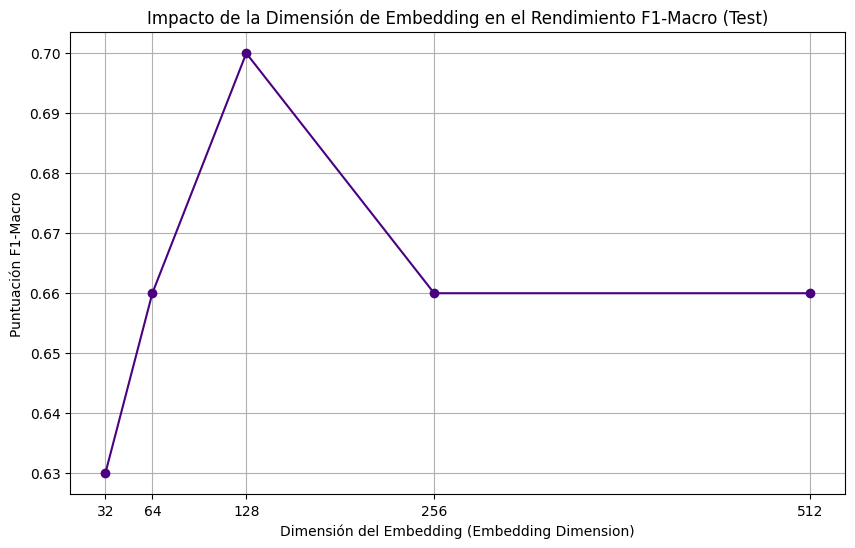


--- Resumen de Resultados ---
Mejor rendimiento F1-Macro (0.7000) obtenido con Embedding Dimension: **128**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---

# Define la lista de dimensiones de embedding a probar
embedding_dims_to_test = [32, 64, 128, 256, 512] 

# Inicializa la lista para guardar SOLO el F1-Macro del conjunto de prueba
results_f1_test_macro = []

# Variables fijas del modelo 
vocab_size = num_words + 1  # +1 para el token de padding
lstm_units = 128 
epochs = 50
batch_size = 128

# --- 2. LOOP DE EXPERIMENTACIÓN ---
print("--- Iniciando Experimento de Dimensiones de Embedding (F1 Test) ---")

for embedding_dim in embedding_dims_to_test:
    
    tf.keras.backend.clear_session() # Limpia la sesión para evitar acumulación de modelos
    
    print(f"\n[INFO] Probando embedding_dim = {embedding_dim}...")

    # A. Definición del Modelo
    modelo_basico = Sequential([
        # Capa Embedding (¡La variable cambia aquí!)
        Embedding(input_dim=vocab_size, output_dim=embedding_dim),

        # LSTM
        Bidirectional(
            LSTM(
                units=lstm_units,
                return_sequences=True
            )
        ),

        # Capa Dense
        Dense(128, activation='relu'),

        # Capa Dense con Softmax (salida)
        Dense(num_classes, activation='softmax')
    ])

    # B. Compilación
    modelo_basico.compile(
        optimizer='adam',
        loss=focal_loss,
        metrics=macro_f1 
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # C. Entrenamiento
    history = modelo_basico.fit(
        train_pad_sequences,
        train_labels_one_hot,
        validation_data=(val_pad_sequences, val_labels_one_hot),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # D. Evaluación en el Conjunto de Prueba
    print("Evaluando en el conjunto de prueba...")
    preds = modelo_basico.predict(test_pad_sequences)
    test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
    preds_idx = preds_to_index(preds, len_test_sequences)
    resultado = classification_report(test_labels_idx, preds_idx, zero_division=1.0)
    
    f1_test = extract_macro_f1(resultado)
    
    # Guardar el resultado
    results_f1_test_macro.append(f1_test)
    
    print(f"F1-Macro en Test para dim={embedding_dim}: {f1_test:.4f}")

# --- 3. GRÁFICA DE RESULTADOS ---
print("\n--- Generando Gráfica de Resultados ---")

plt.figure(figsize=(10, 6))
plt.plot(embedding_dims_to_test, results_f1_test_macro, marker='o', linestyle='-', color='indigo')

plt.title('Impacto de la Dimensión de Embedding en el Rendimiento F1-Macro (Test)')
plt.xlabel('Dimensión del Embedding (Embedding Dimension)')
plt.ylabel('Puntuación F1-Macro')
plt.xticks(embedding_dims_to_test)
plt.grid(True)
plt.show() 

# --- 4. RESUMEN ---
best_dim_index = np.argmax(results_f1_test_macro)
best_dim = embedding_dims_to_test[best_dim_index]
best_f1 = results_f1_test_macro[best_dim_index]

print("\n--- Resumen de Resultados ---")
print(f"Mejor rendimiento F1-Macro ({best_f1:.4f}) obtenido con Embedding Dimension: **{best_dim}**")

In [29]:
best_embedding_dim = best_dim 


 2. **Xarxes Convolucionals.** Afegiu capes convolucionals al vostre model. Expliqueu amb detall els valors que heu provat i la vostra motivació a l'hora d'escollir-los. Recordeu, que també podeu provar diferents configuracions de *pooling*.


In [ ]:
# La mejor dimensión de embedding encontrada
embedding_dim = best_embedding_dim

# Dimensiones a probar (hiperparámetros de Conv1D)
filter_configs = [64, 128, 256]
kernel_configs = [3, 5, 7]

# Variables fijas
vocab_size = num_words + 1  
lstm_units = 128 
epochs = 50
batch_size = 512

# Lista para guardar los resultados: (Filtros, Kernel, F1-Macro Test)
results_data = [] 
best_f1 = 0.0
best_config = {}

# --- 2. LOOP DE EXPERIMENTACIÓN ---
print("--- Iniciando Experimento de Configuración Conv1D ---")

for filters in filter_configs:
    for kernel_size in kernel_configs:
        
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED_VALUE) # Volver a fijar la seed por precaución
        
        config_name = f"Filtros={filters}, Kernel={kernel_size}"
        print(f"\n[INFO] Probando configuración: {config_name}...")

        # A. Definición del Modelo Híbrido
        modelo_hibrido = Sequential([
            # Capa Embedding
            Embedding(input_dim=vocab_size, output_dim=embedding_dim),
                  
            # Conv1D (Parámetros variables)
            Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                padding='same',
                activation='relu'
            ),
            # modelo_hibrido.summary()
            # GlobalMaxPooling1D(poolsize=2),
            # Bi-LSTM
            Bidirectional(
                LSTM(
                    units=lstm_units,
                    return_sequences=True
                )
            ),
            # modelo_hibrido.summary()
            # GlobalMaxPooling1D(poolsize=2),
                
            # Capas Dense para Etiquetado de Secuencia
            Dense(128, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])

        # B. Compilación 
        modelo_hibrido.compile(
            optimizer='adam',
            loss=focal_loss,
            metrics=macro_f1
        )
        
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        # C. Entrenamiento
        history = modelo_hibrido.fit(
            train_pad_sequences, train_labels_one_hot,
            validation_data=(val_pad_sequences, val_labels_one_hot),
            epochs=epochs, batch_size=batch_size,
            callbacks=[early_stop], verbose=0
        )

        # D. Evaluación en el Conjunto de Prueba
        preds = modelo_hibrido.predict(test_pad_sequences)
        test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
        preds_idx = preds_to_index(preds, len_test_sequences)
        resultado = classification_report(test_labels_idx, preds_idx, zero_division=1.0)
        f1_test = extract_macro_f1(resultado)
        
        results_data.append((filters, kernel_size, f1_test))
        
        print(f"F1-Macro Test para {config_name}: {f1_test:.4f}")
        
        if f1_test > best_f1:
            best_f1 = f1_test
            best_config = {'filters': filters, 'kernel_size': kernel_size}

# --- 3. RESUMEN DE RESULTADOS ---
print("\n--- Resumen de Resultados ---")
for filters, kernel_size, f1_test in results_data:
    print(f"Filtros={filters}, Kernel={kernel_size}: F1-Macro={f1_test:.4f}")

print(f"\nMejor configuración encontrada: Filtros={best_config['filters']}, Kernel={best_config['kernel_size']} con F1-Macro de {best_f1:.4f}")

NameError: name 'best_embedding_dim' is not defined


 3. **Xarxes Recurrents.**  Afegiu capes recurrents al vostre model (LSTM, GRU). Expliqueu amb detall els valors que heu provat i la vostra motivació.


--- Iniciando Experimento de Arquitecturas Recurrentes (Embedding=128) ---

[INFO] Probando arquitectura: Bi-LSTM...
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
F1-Macro en Test para Bi-LSTM: 0.6600
--- Classification Report para Bi-LSTM ---

[INFO] Probando arquitectura: Bi-GRU...
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
F1-Macro en Test para Bi-GRU: 0.7000
--- Classification Report para Bi-GRU ---

[INFO] Probando arquitectura: LSTM Unidireccional...
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
F1-Macro en Test para LSTM Unidireccional: 0.6200
--- Classification Report para LSTM Unidireccional ---

--- Generando Gráfica de Resultados ---


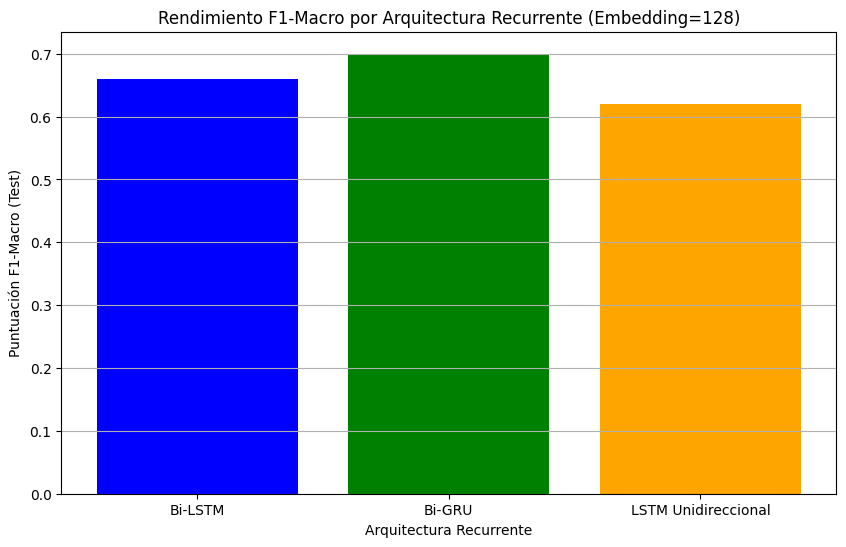


--- Resumen Final ---
Mejor rendimiento F1-Macro (0.7000) obtenido con la arquitectura: **Bi-GRU**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---

# La mejor dimensión de embedding encontrada y fija
embedding_dim = best_embedding_dim 

# Variables fijas
vocab_size = num_words + 1 
lstm_units = 128 
epochs = 50
batch_size = 128

# Arquitecturas a probar: (Nombre, Capa Recurrente)
rnn_configs = [
    ("Bi-LSTM", lambda units: Bidirectional(LSTM(units=units, return_sequences=True))),
    ("Bi-GRU", lambda units: Bidirectional(GRU(units=units, return_sequences=True))),
    ("LSTM Unidireccional", lambda units: LSTM(units=units, return_sequences=True)),
]

# Lista para guardar los resultados: (Nombre_Modelo, F1-Macro Test)
results_f1_test_macro = []
results_labels = []

# --- 2. LOOP DE EXPERIMENTACIÓN ---
print(f"--- Iniciando Experimento de Arquitecturas Recurrentes (Embedding={embedding_dim}) ---")

for name, rnn_layer_fn in rnn_configs:
    
    tf.keras.backend.clear_session() 
    tf.random.set_seed(SEED_VALUE) 
    
    print(f"\n[INFO] Probando arquitectura: {name}...")

    # A. Definición del Modelo
    modelo = Sequential([
        # Capa Embedding (Fija)
        Embedding(input_dim=vocab_size, output_dim=embedding_dim),

        # Capa Recurrente (VARIABLE)
        rnn_layer_fn(lstm_units),

        # Capa Dense intermedia
        Dense(128, activation='relu'),

        # Capa Dense con Softmax (salida para Etiquetado de Secuencia)
        Dense(num_classes, activation='softmax')
    ])

    # B. Compilación
    modelo.compile(
        optimizer='adam',
        loss=focal_loss,
        metrics=macro_f1 
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # C. Entrenamiento
    history = modelo.fit(
        train_pad_sequences,
        train_labels_one_hot, 
        validation_data=(val_pad_sequences, val_labels_one_hot),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # D. Evaluación en el Conjunto de Prueba
    preds = modelo.predict(test_pad_sequences)
    test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
    preds_idx = preds_to_index(preds, len_test_sequences)
    resultado = classification_report(test_labels_idx, preds_idx, zero_division=1.0)
    
    f1_test = extract_macro_f1(resultado)
    
    # Guardar el resultado
    results_f1_test_macro.append(f1_test)
    results_labels.append(name)
    
    print(f"F1-Macro en Test para {name}: {f1_test:.4f}")
    print(f"--- Classification Report para {name} ---")
    

# --- 3. GRÁFICA DE RESULTADOS ---
print("\n--- Generando Gráfica de Resultados ---")

plt.figure(figsize=(10, 6))
plt.bar(results_labels, results_f1_test_macro, color=['blue', 'green', 'orange'])

plt.title(f'Rendimiento F1-Macro por Arquitectura Recurrente (Embedding={embedding_dim})')
plt.xlabel('Arquitectura Recurrente')
plt.ylabel('Puntuación F1-Macro (Test)')
plt.grid(axis='y')
plt.show() 

# --- 4. RESUMEN ---
best_index = np.argmax(results_f1_test_macro)
best_name = results_labels[best_index]
best_f1 = results_f1_test_macro[best_index]

print("\n--- Resumen Final ---")
print(f"Mejor rendimiento F1-Macro ({best_f1:.4f}) obtenido con la arquitectura: **{best_name}**")


 4.  **Transformer**. Afegiu blocs de Transformer al vostre model. Expliqueu amb detall els valors que heu provat i la vostra motivació.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report
import random # Importamos el módulo random para la búsqueda

# --- 1. CONFIGURACIÓN BASE ---
embedding_dim = 128 
epochs = 150 
batch_size = 512 
SEED_VALUE = 42
tf.random.set_seed(SEED_VALUE) 

# --- 2. RANGOS Y DISTRIBUCIONES DE HIPERPARÁMETROS A PROBAR ---

# Número de cabezas (Divisor de embedding_dim = 128)
num_heads_options = [4, 8, 16] 

# Multiplicadores de ff_dim
ff_dim_multipliers_options = [3, 4, 6] 

# Lista para guardar los resultados: (GRU_units, num_heads, ff_dim, dropout_rate, F1-Macro)
results_hybrid = []

print(f"--- Iniciando Búsqueda Aleatoria (Randomized Search) en {N_ITER} iteraciones ---")

# --- 3. BUCLE DE EXPERIMENTACIÓN (RANDOMIZED SEARCH) ---

for num_heads in num_heads_options:
    for multiplier in ff_dim_multipliers_options:

    
        # 1. Selección Aleatoria de Hiperparámetros
        num_heads = num_heads
        multiplier = multiplier
        
        ff_dim = multiplier * embedding_dim
        
        # Verificación de divisibilidad (num_heads debe dividir a embed_dim)
        if embedding_dim % num_heads != 0:
            continue # Ignoramos combinaciones inválidas si se estuviera probando un rango más amplio.
        
        
        tf.keras.backend.clear_session() 
        tf.random.set_seed(SEED_VALUE + i) # Cambiamos la semilla para mayor aleatoriedad

        # A. Definición del Modelo Híbrido
        # La Bi-GRU tiene una salida de 2 * gru_units    
        modelo = Sequential([
            # 0. Capa Embedding
            TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim),
            # 2. Bloque Transformer (VARIABLE)
            TransformerBlock(
                embed_dim=embedding_dim, 
                num_heads=num_heads, 
                ff_dim=ff_dim,
            ), 
            # 3. Clasificación Final
            Dense(128, activation='relu'),
            Dense(num_classes, activation='softmax')
        ])

        # B. Compilación (Se mantiene igual)
        modelo.compile(
            optimizer='adam',
            loss=focal_loss,
            metrics=macro_f1 
        )
        
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        # C. Entrenamiento (Verbose reducido para el Search)
        modelo.fit(
            train_pad_sequences,
            train_labels_one_hot,
            validation_data=(val_pad_sequences, val_labels_one_hot),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=1
        )

        # D. Evaluación y Reporte
        preds = modelo.predict(test_pad_sequences)
        test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
        preds_idx = preds_to_index(preds, len_test_sequences)
        resultado = classification_report(test_labels_idx, preds_idx, zero_division=1.0)
        
        f1_test = extract_macro_f1(resultado)    
        results_hybrid.append((num_heads, ff_dim, f1_test))
        

# --- 4. RESUMEN FINAL DE RANDOMIZED SEARCH ---
results_hybrid.sort(key=lambda x: x[2], reverse=True)
best_config = results_hybrid[0]

print("\n--- Resumen Final del Randomized Search Híbrido ---")
print(f"Mejor rendimiento F1-Macro ({best_config[2]:.4f}) obtenido con:")
print(f"  - num_heads (Transf): **{best_config[0]}**")
print(f"  - ff_dim (Transf): **{best_config[1]}**")


 5. **Regularització.** Quan proveu configuracions amb més paràmetres veureu que el model comença a tenir *overfitting* molt prompte durant l'entrenament. Afegiu *Dropout* al vostre model. Heu d'explicar la vostra decisió de valors i de posició dins de la xarxa.


Vamos a hacer las 2 cosas juntas introduciendo una randomized search, algoritmo que está demostrado que funciona bastante bien, ya que está demostrado que hay bastantes configuraciones que se acercan bastante a la óptima, por lo tanto es mucho más eficiente probar una selección aleatoria y encontrar alguna cercana.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report
import random # Importamos el módulo random para la búsqueda

# --- 1. CONFIGURACIÓN BASE ---
embedding_dim = 128 
epochs = 150 
batch_size = 512 
SEED_VALUE = 42
tf.random.set_seed(SEED_VALUE) 

# Parámetro de regularización L2 (lo dejamos fijo por simplicidad)
l2_rate = 1e-4 

# --- 2. RANGOS Y DISTRIBUCIONES DE HIPERPARÁMETROS A PROBAR ---

# Unidades de la GRU (Deben ser divisibles por 128 o 256 para ser eficientes)
gru_units_options = [64, 128] # Probaremos unidades más pequeñas y las actuales

# Número de cabezas (Divisor de embedding_dim = 128)
num_heads_options = [4, 8, 16] 

# Tasa de Dropout (distribución uniforme de 0.1 a 0.4)
dropout_rate_range = (0.1, 0.4) 

# Multiplicadores de ff_dim
ff_dim_multipliers_options = [3, 4, 6] 

# Definimos el número total de combinaciones (ITERACIONES) a probar
N_ITER = 15 

# Lista para guardar los resultados: (GRU_units, num_heads, ff_dim, dropout_rate, F1-Macro)
results_hybrid_random = []

print(f"--- Iniciando Búsqueda Aleatoria (Randomized Search) en {N_ITER} iteraciones ---")

# --- 3. BUCLE DE EXPERIMENTACIÓN (RANDOMIZED SEARCH) ---

for i in range(N_ITER):
    
    # 1. Selección Aleatoria de Hiperparámetros
    num_heads = random.choice(num_heads_options)
    multiplier = random.choice(ff_dim_multipliers_options)
    dropout_rate = round(random.uniform(*dropout_rate_range), 2) # Tomamos un valor aleatorio entre 0.1 y 0.4
    
    ff_dim = multiplier * embedding_dim
    
    # Verificación de divisibilidad (num_heads debe dividir a embed_dim)
    if embedding_dim % num_heads != 0:
        continue # Ignoramos combinaciones inválidas si se estuviera probando un rango más amplio.
    
    name = f"Iter-{i+1:02d} | H{num_heads}-FF{ff_dim}-D{dropout_rate}"
    print(f"\n[INFO] Probando configuración: {name}...")
    
    tf.keras.backend.clear_session() 
    tf.random.set_seed(SEED_VALUE + i) # Cambiamos la semilla para mayor aleatoriedad

    # A. Definición del Modelo Híbrido
    # La Bi-GRU tiene una salida de 2 * gru_units
    
    modelo = Sequential([
        # 0. Capa Embedding
        TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim), 
        
        Dropout(dropout_rate), #  DROPOUT variable
        
        # 2. Bloque Transformer (VARIABLE)
        TransformerBlock(
            embed_dim=embedding_dim, 
            num_heads=num_heads, 
            ff_dim=ff_dim,
            rate=dropout_rate # Usamos la misma tasa de dropout para la regularización interna del Transformer
        ), 
        
        # 3. Clasificación Final
        Dense(128, activation='relu', kernel_regularizer=l2(l2_rate)),
        Dropout(dropout_rate), #  DROPOUT variable
        Dense(num_classes, activation='softmax')
    ])

    # B. Compilación (Se mantiene igual)
    modelo.compile(
        optimizer='adam',
        loss=focal_loss,
        metrics=macro_f1 
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # C. Entrenamiento (Verbose reducido para el Search)
    modelo.fit(
        train_pad_sequences,
        train_labels_one_hot,
        validation_data=(val_pad_sequences, val_labels_one_hot),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    # D. Evaluación y Reporte
    preds = modelo.predict(test_pad_sequences)
    test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
    preds_idx = preds_to_index(preds, len_test_sequences)
    resultado = classification_report(test_labels_idx, preds_idx, zero_division=1.0)
    
    f1_test = extract_macro_f1(resultado)    
    results_hybrid_random.append((num_heads, ff_dim, dropout_rate, f1_test))
    
    print(f"F1-Macro Test para {name}: {f1_test:.4f}")

# --- 4. RESUMEN FINAL DE RANDOMIZED SEARCH ---
results_hybrid_random.sort(key=lambda x: x[3], reverse=True)
best_config = results_hybrid_random[0]

print("\n--- Resumen Final del Randomized Search Híbrido ---")
print(f"Mejor rendimiento F1-Macro ({best_config[3]:.4f}) obtenido con:")
print(f"  - num_heads (Transf): **{best_config[0]}**")
print(f"  - ff_dim (Transf): **{best_config[1]}**")
print(f"  - Dropout Rate: **{best_config[2]}**")

--- Iniciando Búsqueda Aleatoria (Randomized Search) en 15 iteraciones ---

[INFO] Probando configuración: Iter-01 | G64-H16-FF384-D0.11...
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - loss: 0.4404 - macro_f1_3d: 0.1277 - val_loss: 0.1504 - val_macro_f1_3d: 0.0080
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.1461 - macro_f1_3d: 0.0080 - val_loss: 0.1328 - val_macro_f1_3d: 0.0080
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.1331 - macro_f1_3d: 0.0081 - val_loss: 0.1242 - val_macro_f1_3d: 0.0080
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.1262 - macro_f1_3d: 0.0082 - val_loss: 0.1187 - val_macro_f1_3d: 0.0080
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.1222 - macro_f1_3d: 0.0082 - val_loss: 0.1149 - val_macro_f1_3d: 0.0080
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.1193 - macro_f1_3d: 0.0084 - val_loss: 0.1135 - val_macro_f1_3d: 0.0080
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.1169 - macro_f1_3d: 0

In [37]:
print(results_hybrid_random)


[(64, 8, 512, 0.28, 0.72), (64, 4, 512, 0.16, 0.71), (64, 4, 768, 0.2, 0.71), (64, 4, 512, 0.28, 0.7), (128, 16, 512, 0.17, 0.7), (128, 8, 384, 0.34, 0.7), (64, 8, 384, 0.17, 0.69), (64, 16, 384, 0.11, 0.68), (128, 16, 768, 0.16, 0.68), (64, 16, 384, 0.29, 0.68), (64, 16, 768, 0.26, 0.67), (64, 16, 512, 0.28, 0.67), (64, 4, 512, 0.12, 0.67), (128, 16, 512, 0.34, 0.66), (64, 16, 768, 0.25, 0.64)]




 6. **Balancejat de les classes.** Si analitzeu el dataset, veureu que la freqüència de les classes està molt desbalancejada. Keras us permet afegir un pes per a cada classe a l'hora de calcular la loss (Mireu el paràmetre "class_weigth" a la documentació https://keras.io/api/models/model_training_apis/). Calculeu un pes per a cada classe i afegiu-lo al mètode fit del vostre model.

 ---

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Aplanar todas las etiquetas numéricas del conjunto de entrenamiento
all_labels_flat = train_pad_labels.flatten()

# Obtener las clases únicas (los índices numéricos de 0 a 118)
class_indices = np.unique(all_labels_flat)

# Calcular los pesos en modo 'balanced' (frecuencia inversa)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=class_indices,
    y=all_labels_flat
)

# Crear el diccionario que mapea el índice de la clase a su peso
class_weight_dict = dict(zip(class_indices, class_weights_array))

print("Diccionario de pesos de clase calculado.")
# Copiamos la estructura de las etiquetas numéricas de entrenamiento
sample_weight_array = np.copy(train_pad_labels).astype('float32')

# Reemplazamos cada índice de clase en el array por su peso del diccionario
for class_idx, weight in class_weight_dict.items():
    sample_weight_array[sample_weight_array == class_idx] = weight

print(f"Array de sample_weight creado con shape: {sample_weight_array.shape}")

Pesos de clase calculados y limitados a un máximo de 20.0


In [ ]:
embedding_dim = 128 
epochs = 150 
batch_size = 512 
SEED_VALUE = 42

# Parámetro de regularización L2 (lo dejamos fijo por simplicidad)
l2_rate = 1e-4 

# 1. Mejores hiperparámetros
num_heads = best_config[0]
multiplier = best_config[1] // embedding_dim
dropout_rate = best_config[2]

ff_dim = multiplier * embedding_dim

name = f"Iter-{i+1:02d} | H{num_heads}-FF{ff_dim}-D{dropout_rate}"
print(f"\n[INFO] Probando configuración: {name}...")


# A. Definición del Modelo Híbrido
# La Bi-GRU tiene una salida de 2 * gru_units
lstm_output_dim = 2 * gru_units

modelo = Sequential([
    # 0. Capa Embedding
    TokenAndPositionEmbedding(max_len, vocab_size, embedding_dim),
    Dropout(dropout_rate), #  DROPOUT variable
    
    # 2. Bloque Transformer (VARIABLE)
    TransformerBlock(
        embed_dim=embedding_dim, 
        num_heads=num_heads, 
        ff_dim=ff_dim,
        rate=dropout_rate # Usamos la misma tasa de dropout para la regularización interna del Transformer
    ), 
    
    # 3. Clasificación Final
    Dense(128, activation='relu', kernel_regularizer=l2(l2_rate)),
    Dropout(dropout_rate), #  DROPOUT variable
    Dense(num_classes, activation='softmax')
])

# B. Compilación (Se mantiene igual)
modelo.compile(
    optimizer='adam',
    loss=focal_loss_temporal,
    metrics=macro_f1 
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# C. Entrenamiento (Verbose reducido para el Search)
modelo.fit(
    train_pad_sequences,
    train_labels_one_hot,
    validation_data=(val_pad_sequences, val_labels_one_hot),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    sample_weight=sample_weight_array,
    verbose=1
)

# D. Evaluación y Reporte
preds = modelo.predict(test_pad_sequences)
test_labels_idx = preds_to_index(test_labels_one_hot,len_test_sequences)
preds_idx = preds_to_index(preds, len_test_sequences)
resultado = classification_report(test_labels_idx, preds_idx, zero_division=1.0)

f1_test = extract_macro_f1(resultado)
results_hybrid_random.append((num_heads, ff_dim, dropout_rate, f1_test))

print(f"F1-Macro Test para {name}: {f1_test:.4f}")

# Generar Classification Report
print(resultado)





[INFO] Probando configuración: Iter-04 | G64-H8-FF512-D0.28...
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - loss: 0.5491 - macro_f1_3d: 0.0438 - val_loss: 0.9196 - val_macro_f1_3d: 0.0304
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 571ms/step - loss: 0.4736 - macro_f1_3d: 0.0145 - val_loss: 0.5718 - val_macro_f1_3d: 0.0730
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step - loss: 0.3690 - macro_f1_3d: 0.0430 - val_loss: 0.3637 - val_macro_f1_3d: 0.1329
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 574ms/step - loss: 0.2758 - macro_f1_3d: 0.0847 - val_loss: 0.2528 - val_macro_f1_3d: 0.1864
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 573ms/step - loss: 0.2094 - macro_f1_3d: 0.1306 - val_loss: 0.2537 - val_macro_f1_3d: 0.2233
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 581ms/step - loss: 0.1635 - macro_f1_3d: 0.1646 - val_loss: 0.2163 - val_macro_f1_3d: 0.2451
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 594ms/step - loss: 0.1345 - macro_f1_3d: 0.1892 - val_loss: 0.2085 - val_macro_f1_3d: 0.2438
Epoch

In [40]:
print(results_hybrid_random)

[(64, 8, 512, 0.28, 0.72), (64, 4, 512, 0.16, 0.71), (64, 4, 768, 0.2, 0.71), (64, 4, 512, 0.28, 0.7), (128, 16, 512, 0.17, 0.7), (128, 8, 384, 0.34, 0.7), (64, 8, 384, 0.17, 0.69), (64, 16, 384, 0.11, 0.68), (128, 16, 768, 0.16, 0.68), (64, 16, 384, 0.29, 0.68), (64, 16, 768, 0.26, 0.67), (64, 16, 512, 0.28, 0.67), (64, 4, 512, 0.12, 0.67), (128, 16, 512, 0.34, 0.66), (64, 16, 768, 0.25, 0.64), (64, 8, 512, 0.28, 0.69)]


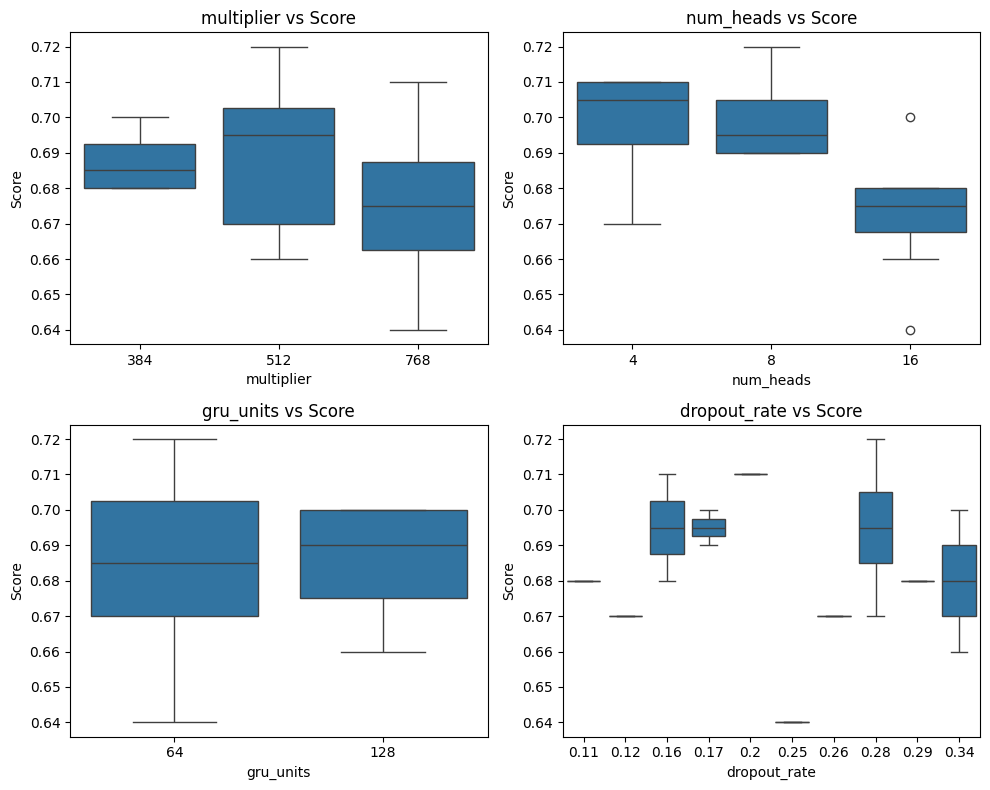

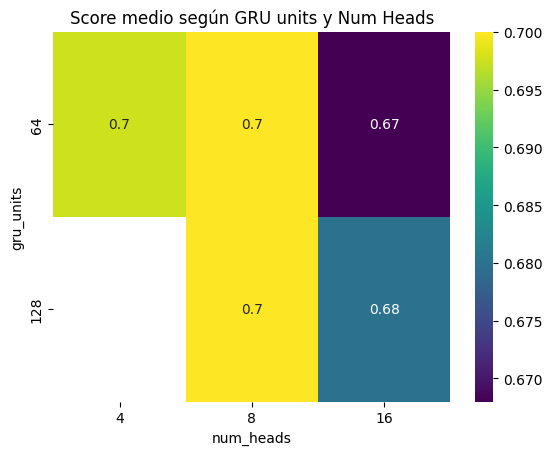

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Supongamos que ya tenés tu DataFrame con:
# cols = ['gru_units', 'num_heads', 'multiplier', 'dropout_rate', 'score']
df = pd.DataFrame(results_hybrid_random, columns=['gru_units', 'num_heads', 'multiplier', 'dropout_rate', 'score'])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Orden personalizado (arriba: multiplier y num_heads)
params = ['multiplier', 'num_heads', 'gru_units', 'dropout_rate']

for ax, param in zip(axes, params):
    sns.boxplot(x=param, y='score', data=df, ax=ax)
    ax.set_title(f'{param} vs Score')
    ax.set_xlabel(param)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.show()

import seaborn as sns
pivot = df.pivot_table(values='score', index='gru_units', columns='num_heads', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='viridis')
plt.title('Score medio según GRU units y Num Heads')
plt.show()


---

<h1><a name="section-four"> 4. Lliurable </a></h1>

Heu d'entregar un document PDF de com a **màxim 10 pàgines** que incloga els resultats de tots els exercicis així com una explicació de cadascun dels resultats i de la modificació que heu fet. L'estructura del document és:

1. Introducció.
2. Experiments i Resultats (amb raonament).
3. Conclusions.

No cal que afegiu el vostre codi al document, podeu entregar el *notebook* juntament amb el document.

 ---

- falta hacer modelo transformer básico
- probar transformer sin GRU
- Probar mas de meter el pooling cuando meto una convolucional